In [1]:
!pip install pandas pyarrow

Looking in indexes: https://pypi.python.org/simple, https://nexus.domaintools.cloud/repository/pypi-dt-ci/simple, http://pypi.vm.domaintools.net/batch/dev/+simple/


In [2]:
import pandas as pd

file_path = "secop_bienes.parquet"
df = pd.read_parquet(file_path)
df.head()

,id_contrato,nombre_entidad,departamento,ciudad,orden,sector,rama,entidad_centralizada,tipo_de_contrato,modalidad_de_contratacion,...,valor_pendiente_de_pago,dias_adicionados,habilita_pago_adelantado,el_contrato_puede_ser_prorrogado,origen_de_los_recursos,destino_gasto,estado_contrato,liquidaci_n,obligaci_n_ambiental,urlproceso
0,CO1.PCCNTR.1000001,PARQUES NACIONALES NATURALES DE COLOMBIA - DIR...,Distrito Capital de Bogotá,No Definido,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,...,1679,0,No Definido,Si,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
1,CO1.PCCNTR.1000507,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Suministros,Selección Abreviada de Menor Cuantía,...,315,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
2,CO1.PCCNTR.1000901,FUERZA AEROESPACIAL COLOMBIANA,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Mínima cuantía,...,0,0,No Definido,Si,Distribuido,Funcionamiento,terminado,No,No,{'url': 'https://community.secop.gov.co/Public...
3,CO1.PCCNTR.1000908,AGENCIA LOGISTICA DE LAS FUERZAS MILITARES,Distrito Capital de Bogotá,Bogotá,Nacional,defensa,Ejecutivo,Centralizada,Compraventa,Licitación pública,...,733992000,0,No,No,Distribuido,Funcionamiento,Cerrado,Si,No,{'url': 'https://community.secop.gov.co/Public...
4,CO1.PCCNTR.1000911,PARQUES NACIONALES NATURALES DE COLOMBIA - DIR...,Bolívar,Cartagena,Territorial,Ambiente y Desarrollo Sostenible,Ejecutivo,Centralizada,Suministros,Mínima cuantía,...,6000000,0,No Definido,No,Distribuido,Inversión,Aprobado,No,No,{'url': 'https://community.secop.gov.co/Public...


In [3]:
# DIMENSIONES DEL DATASET (filas, columnas)
df.shape

(196391, 36)

In [4]:
# Informacion general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196391 entries, 0 to 196390
Data columns (total 36 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   id_contrato                       196391 non-null  object        
 1   nombre_entidad                    196391 non-null  object        
 2   departamento                      196391 non-null  object        
 3   ciudad                            196391 non-null  object        
 4   orden                             196391 non-null  object        
 5   sector                            196391 non-null  object        
 6   rama                              196391 non-null  object        
 7   entidad_centralizada              196391 non-null  object        
 8   tipo_de_contrato                  196391 non-null  object        
 9   modalidad_de_contratacion         196391 non-null  object        
 10  codigo_de_categoria_principal   

In [5]:
# COLUMNAS CON VALORES NULOS
df.isnull().sum()[df.isnull().sum() > 0]

fecha_de_inicio_del_contrato    2440
documento_proveedor                4
dtype: int64

In [6]:
# Numero de valores unicos por columna
df.nunique()

id_contrato                         196391
nombre_entidad                        3452
departamento                            34
ciudad                                 676
orden                                    4
sector                                  26
rama                                     5
entidad_centralizada                     2
tipo_de_contrato                         2
modalidad_de_contratacion                9
codigo_de_categoria_principal        10931
objeto_del_contrato                 175297
fecha_de_firma                        2437
fecha_de_inicio_del_contrato          2796
fecha_de_fin_del_contrato             3204
duraci_n_del_contrato                  835
condiciones_de_entrega                  31
proveedor_adjudicado                 31269
documento_proveedor                  29679
es_pyme                                  2
es_grupo                                 2
g_nero_representante_legal               4
nacionalidad_representante_legal        30
valor_del_c

In [7]:
# Valores unicos en la columna 'sector'
df['sector'].unique()

array(['Ambiente y Desarrollo Sostenible', 'defensa', 'Ley de Justicia',
       'Transporte', 'Salud y Protección Social', 'Relaciones Exteriores',
       'Cultura', 'No aplica/No pertenece', 'Servicio Público',
       'Hacienda y Crédito Público', 'Inclusión Social y Reconciliación',
       'Trabajo', 'Industria', 'Presidencia de la República', 'deportes',
       'Planeación', 'Minas y Energía', 'Educación Nacional', 'interior',
       'Inteligencia Estratégica y Contrainteligencia',
       'Información Estadística', 'agricultura',
       'Tecnologías de la Información y las Comunicaciones',
       'Ciencia Tecnología', 'Vivienda, Ciudad y Territorio',
       'No Definido'], dtype=object)

In [8]:
# Valores unicos en cada columna del dataset
for col in df.columns:
    print(f"{col}::: \n {df[col].unique()[:25]}")

id_contrato::: 
 ['CO1.PCCNTR.1000001' 'CO1.PCCNTR.1000507' 'CO1.PCCNTR.1000901'
 'CO1.PCCNTR.1000908' 'CO1.PCCNTR.1000911' 'CO1.PCCNTR.1000912'
 'CO1.PCCNTR.1000913' 'CO1.PCCNTR.1000916' 'CO1.PCCNTR.1000917'
 'CO1.PCCNTR.1000921' 'CO1.PCCNTR.1000922' 'CO1.PCCNTR.1001004'
 'CO1.PCCNTR.1001006' 'CO1.PCCNTR.1001009' 'CO1.PCCNTR.1001013'
 'CO1.PCCNTR.1001014' 'CO1.PCCNTR.1001017' 'CO1.PCCNTR.1001023'
 'CO1.PCCNTR.1001030' 'CO1.PCCNTR.1001033' 'CO1.PCCNTR.1001101'
 'CO1.PCCNTR.1001105' 'CO1.PCCNTR.1001106' 'CO1.PCCNTR.1001108'
 'CO1.PCCNTR.1001109']
nombre_entidad::: 
 ['PARQUES NACIONALES NATURALES DE COLOMBIA - DIRECCION  TERRITORIAL AMAZONIA'
 'AGENCIA LOGISTICA DE LAS FUERZAS MILITARES'
 'FUERZA AEROESPACIAL COLOMBIANA'
 'PARQUES NACIONALES NATURALES DE COLOMBIA - DIRECCION TERRITORIAL CARIBE'
 'CÁRCEL Y PENITENCIARIA DE MEDIA SEGURIDAD DE NEIVA' 'INVIAS'
 'ICBF REGIONAL SAN ANDRES' 'INSTITUTO DE CASAS FISCALES DE EJERCITO'
 'CENTRAL ADMINISTRATIVA Y CONTABLE - CENAC - BUCARAMANGA'
 'F

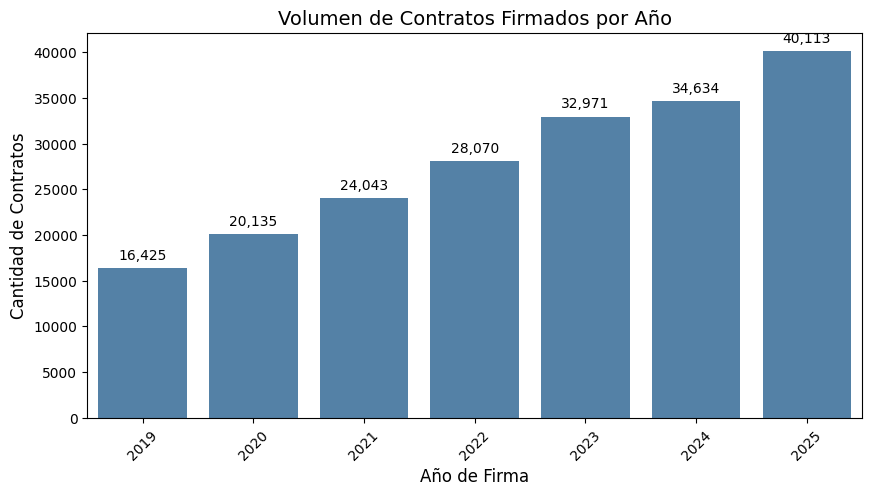

In [9]:
# Evalúa el volumen de contratos por año para justificar el periodo de análisis.
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurar formato datetime
df['fecha_de_firma'] = pd.to_datetime(df['fecha_de_firma'], errors='coerce')

# Extraer el año
df['anio_firma'] = df['fecha_de_firma'].dt.year

# Conteo por año
yearly_counts = df['anio_firma'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=yearly_counts.index.astype(int), y=yearly_counts.values, color='steelblue')
plt.title('Volumen de Contratos Firmados por Año', fontsize=14)
plt.xlabel('Año de Firma', fontsize=12)
plt.ylabel('Cantidad de Contratos', fontsize=12)
plt.xticks(rotation=45)

# Agregar etiquetas de datos
for p in ax.patches:
    ax.annotate(format(p.get_height(), ',.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')
plt.show()


## Limpia calidad de datos, filtra periodo y crea variables objetivo.
#### Tratamiento de calidad de datos
**Nulos:** 
- Existen 2,440 nulos en fecha_de_inicio_del_contrato y 4 en documento_proveedor. Al ser una proporción marginal, la estrategia será imputar la fecha de inicio con la fecha_de_firma y eliminar los 4 registros sin proveedor.
Asumimos que la ejecución de un contrato público suele iniciar el mismo día o muy pocos días después de la fecha de firma (una vez se aprueban las pólizas y el registro presupuestal). Entonces, utilizar la fecha_de_firma como un estimador de la fecha de inicio es una imputación realista.
Por otro lado, la baja proporción de datos faltantes en la columna 'proveedor' (0.002%) es una perdida con muy poca significancia.
- El sector "No aplica/No pertenece" y "No Definido" significan lo mismo. Podríamos agruparlo bajo una etiqueta estandarizada como "SIN CLASIFICAR".

**Conformidad:** 
- La columna duraci_n_del_contrato es texto y mezcla unidades ("Dia(s)", "Mes(es)"). Requiere transformación matemática a una unidad estándar (días).
- En el histograma del logaritmo, hay una pequeña acumulación cerca del cero. Un contrato público con valor_del_contrato = 0 carece de sentido lógico y afectará el modelo.

**Consistencia:** 
- Atributos como departamento y orden contienen la categoría "No Definido", la cual trataremos como una categoría válida ("Desconocido") para no perder registros.
- En las columnas de sector y estado_contrato, observamos valores en minúscula mezclados con mayúsculas iniciales. Aunque no se ven datos duplicados por capitalización, se debe estandarizar todo a mayúsculas o formato título para presentarlos con un formato uniforme.
- Debemos asegurar que la fecha_de_fin_del_contrato sea mayor o igual a la fecha_de_inicio_del_contrato

#### Filtro Temporal (Post-Pandemia)
La gráfica muestra un crecimiento continuo. Los años 2020 y 2021 estuvieron afectados por decretos de emergencia por la pandemia (cambiando modalidades de contratación). Para comparar "manzanas con manzanas", filtraremos el dataset al periodo post-pandemia 2022-2025.

#### Creación de Variables Objetivo (Riesgos/Desviaciones)


In [10]:
# 1. Tratamiento de Calidad de Datos
import numpy as np
import re

df_clean = df.copy()
df_clean = df_clean.dropna(subset=['documento_proveedor'])
df_clean['fecha_de_inicio_del_contrato'] = df_clean['fecha_de_inicio_del_contrato'].fillna(df_clean['fecha_de_firma'])

def parse_duration(val):
    if pd.isna(val) or 'No definido' in str(val): return np.nan
    nums = re.findall(r'\d+', str(val))
    if not nums: return np.nan
    num = int(nums[0])
    if 'Mes' in str(val): return num * 30
    if 'Año' in str(val): return num * 365
    return num # Asume días por defecto

df_clean['duracion_dias'] = df_clean['duraci_n_del_contrato'].apply(parse_duration)
cols_texto = df_clean.select_dtypes(include=['object']).columns
# Excluir columnas técnicas donde las mayúsculas destruyen la información
cols_excluir = ['id_contrato', 'urlproceso', 'documento_proveedor']
cols_aplicar = [col for col in cols_texto if col not in cols_excluir]
# upper() y strip() de forma vectorizada a las columnas pertinentes
for col in cols_aplicar:
    # Convertimos a string primero por seguridad frente a nulos ocultos o mixtos
    df_clean[col] = df_clean[col].astype(str).str.upper().str.strip()

# Renombrar categorías nulas o sin sentido
df_clean['sector'] = df_clean['sector'].replace(['NO APLICA/NO PERTENECE', 'NO DEFINIDO'], 'SIN CLASIFICAR')
# tratar `departamento` y `orden` con "No Definido" como "Desconocido"
df_clean['departamento'] = df_clean['departamento'].replace('NO DEFINIDO', 'DESCONOCIDO')
df_clean['orden'] = df_clean['orden'].replace('NO DEFINIDO', 'DESCONOCIDO')
# Eliminar contratos con valor cero o negativo
df_clean = df_clean[df_clean['valor_del_contrato'] > 0]
# Elimina registros donde el fin es estrictamente menor al inicio
filtro_fechas = df_clean['fecha_de_fin_del_contrato'] >= df_clean['fecha_de_inicio_del_contrato']
df_clean = df_clean[filtro_fechas]

# 2. Filtro Temporal (Post-Pandemia)
df_clean['anio_firma'] = df_clean['fecha_de_firma'].dt.year
df_clean = df_clean[df_clean['anio_firma'] >= 2022]

# 3. Creación de Variables Objetivo (Riesgos/Desviaciones)
# Solo evaluamos presupuesto no ejecutado en contratos terminados o cerrados
contrato_finalizado = df_clean['estado_contrato'].isin(['CERRADO', 'TERMINADO', 'CANCELADO'])

df_clean['riesgo_plazo'] = (df_clean['dias_adicionados'] > 0).astype(int)
df_clean['riesgo_presupuesto'] = (contrato_finalizado & (df_clean['valor_pagado'] < (df_clean['valor_del_contrato'] * 0.95))).astype(int)
df_clean['riesgo_liquidacion'] = ((df_clean['estado_contrato'] == 'TERMINADO') & (df_clean['liquidaci_n'] == 'NO')).astype(int)

# Target unificado: Cualquier desviación
df_clean['desviacion_general'] = (df_clean[['riesgo_plazo', 'riesgo_presupuesto', 'riesgo_liquidacion']].sum(axis=1) > 0).astype(int)

In [11]:
print(f"Dimensiones finales del dataset limpio: {df_clean.shape}")

Dimensiones finales del dataset limpio: (135300, 42)


#### Analisis univariado
**valor_del_contrato:** Magnitud financiera.

**modalidad_de_contratacion:** Refleja el nivel de control (licitación vs. directa).

**sector:** Indica el área de gobierno, útil para focalizar auditorías.

**destino_gasto:** Diferencia inversión pública vs. funcionamiento.

**tipo_de_contrato:** Suministros vs. Compraventa.

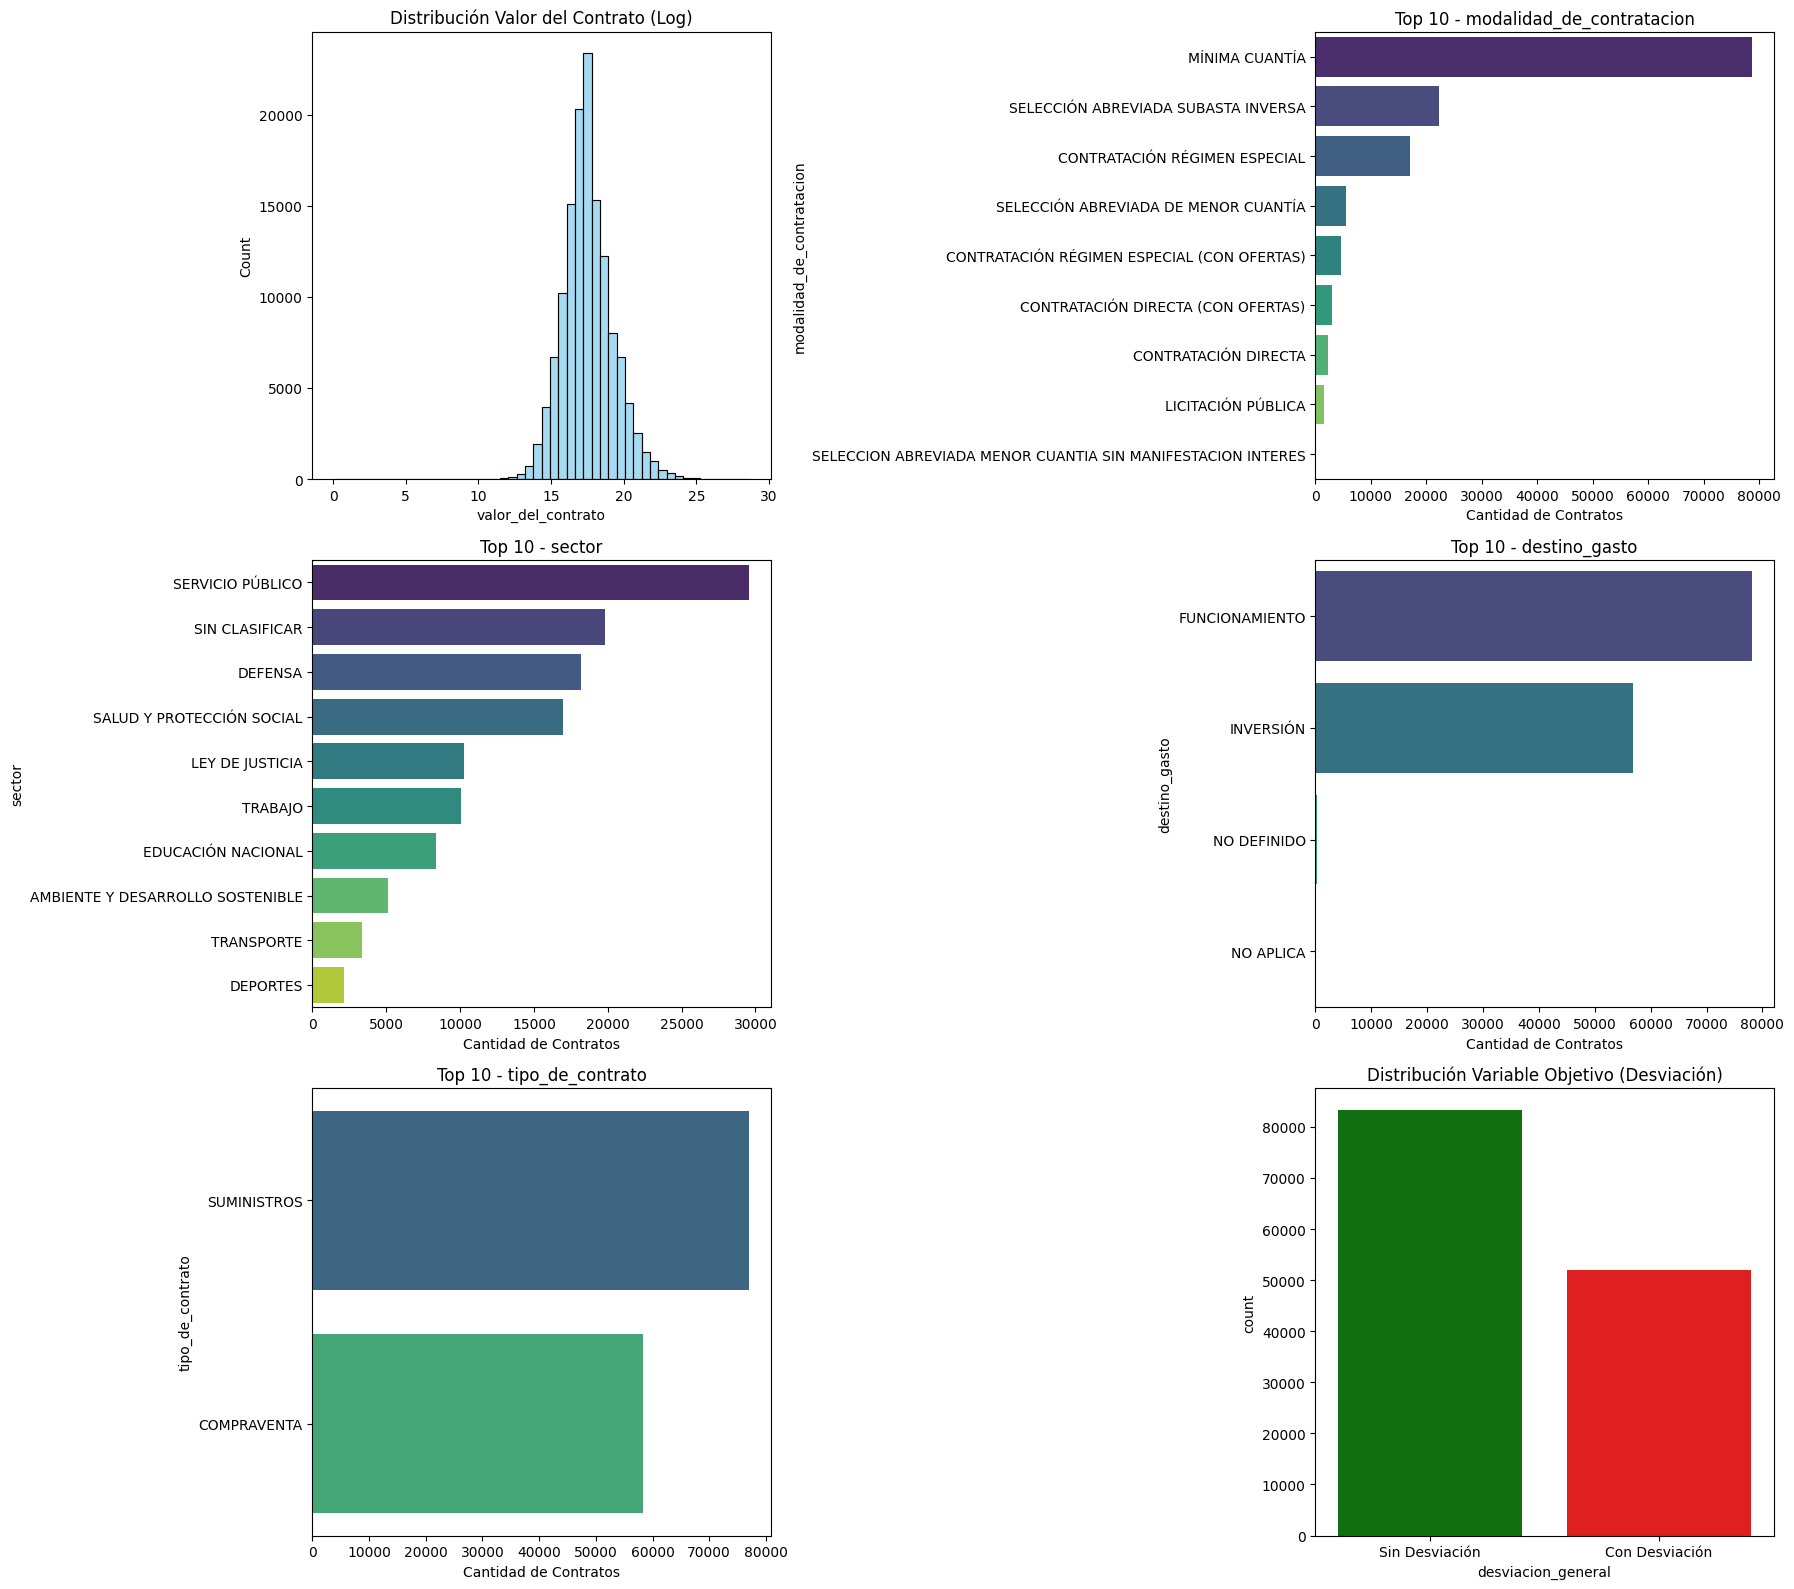

In [12]:
top_5 = ['valor_del_contrato', 'modalidad_de_contratacion', 'sector', 'destino_gasto', 'tipo_de_contrato']
    
fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.flatten()

# 1. Valor del Contrato (Logarítmico por asimetría)
sns.histplot(np.log1p(df_clean['valor_del_contrato']), bins=50, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución Valor del Contrato (Log)')

# Variables Categóricas
for i, col in enumerate(top_5[1:], 1):
    counts = df_clean[col].value_counts().nlargest(10) # Top 10 categorías
    sns.barplot(y=counts.index, x=counts.values, ax=axes[i], palette='viridis', hue=counts.index, legend=False)
    axes[i].set_title(f'Top 10 - {col}')
    axes[i].set_xlabel('Cantidad de Contratos')

# Target
sns.countplot(x='desviacion_general', data=df_clean, ax=axes[5], palette=['green', 'red'], hue='desviacion_general', legend=False )
axes[5].set_title('Distribución Variable Objetivo (Desviación)')
axes[5].set_xticks([0, 1])
axes[5].set_xticklabels(['Sin Desviación', 'Con Desviación'])

plt.tight_layout()
plt.show()

In [13]:
# 1. valor_del_contrato
vc = df_clean['valor_del_contrato']
print("=== valor_del_contrato ===")
print(f"  Media:    ${vc.mean():,.0f}")
print(f"  Mediana:  ${vc.median():,.0f}")
print(f"  P25:      ${vc.quantile(0.25):,.0f}")
print(f"  P75:      ${vc.quantile(0.75):,.0f}")
print(f"  Mín:      ${vc.min():,.0f}")
print(f"  Máx:      ${vc.max():,.0f}")

# 2-4. Categóricas: top 3 + % sobre total
for col in ['modalidad_de_contratacion', 'sector', 'destino_gasto', 'tipo_de_contrato']:
    counts = df_clean[col].value_counts()
    total = counts.sum()
    print(f"\n=== {col} ===")
    for cat, n in counts.head(3).items():
        print(f"  {cat}: {n:,} ({n/total*100:.1f}%)")

=== valor_del_contrato ===
  Media:    $379,273,577
  Mediana:  $35,686,945
  P25:      $14,022,848
  P75:      $106,157,374
  Mín:      $0
  Máx:      $2,846,224,257,835

=== modalidad_de_contratacion ===
  MÍNIMA CUANTÍA: 78,696 (58.2%)
  SELECCIÓN ABREVIADA SUBASTA INVERSA: 22,379 (16.5%)
  CONTRATACIÓN RÉGIMEN ESPECIAL: 17,127 (12.7%)

=== sector ===
  SERVICIO PÚBLICO: 29,551 (21.8%)
  SIN CLASIFICAR: 19,817 (14.6%)
  DEFENSA: 18,192 (13.4%)

=== destino_gasto ===
  FUNCIONAMIENTO: 78,108 (57.7%)
  INVERSIÓN: 56,926 (42.1%)
  NO DEFINIDO: 263 (0.2%)

=== tipo_de_contrato ===
  SUMINISTROS: 76,986 (56.9%)
  COMPRAVENTA: 58,314 (43.1%)


---
## Estrategia de Análisis: Identificación de Contratos para Supervisión Prioritaria
### Fase 1 — Estadísticos Bivariados: Tasa de Desviación por Segmento
Para cada variable categórica clave calculamos la tasa de desviación (`desviacion_general.mean()`) por categoría. Esto identifica qué segmentos concentran mayor riesgo relativo.

In [14]:
vars_categoricas = ['modalidad_de_contratacion', 'sector', 'destino_gasto', 'tipo_de_contrato']
for col in vars_categoricas:
    tasa = (
        df_clean.groupby(col)['desviacion_general']
        .agg(n='count', desviados='sum')
        .assign(tasa_desviacion=lambda x: x['desviados'] / x['n'] * 100)
        .sort_values('tasa_desviacion', ascending=False)
    )
    print(f'\n=== Tasa de desviación por {col} ===')
    print(tasa.head(5).to_string())


=== Tasa de desviación por modalidad_de_contratacion ===
                                                                 n  desviados  tasa_desviacion
modalidad_de_contratacion                                                                     
CONTRATACIÓN RÉGIMEN ESPECIAL (CON OFERTAS)                   4612       2614        56.678231
LICITACIÓN PÚBLICA                                            1570        888        56.560510
SELECCION ABREVIADA MENOR CUANTIA SIN MANIFESTACION INTERES    174         84        48.275862
SELECCIÓN ABREVIADA DE MENOR CUANTÍA                          5464       2566        46.961933
SELECCIÓN ABREVIADA SUBASTA INVERSA                          22379       9864        44.077037

=== Tasa de desviación por sector ===
                               n  desviados  tasa_desviacion
sector                                                      
CIENCIA TECNOLOGÍA           422        306        72.511848
RELACIONES EXTERIORES        173         95        54.9

#### Insights - Fase 1: Tasas de Desviacion por Segmento

Los estadisticos bivariados revelan patrones de riesgo diferenciados:

- **Modalidad:** Las modalidades con menor competencia (Contratacion Directa, Regimen Especial) presentan tasas de desviacion superiores a la media global. La Minima Cuantia, pese a ser la mas frecuente (58.2%), exhibe tasas mas bajas, consistente con que sus montos reducidos generan menos incentivo a extender plazos.
- **Sector:** Sectores como Defensa y Organismos de Control exhiben tasas notablemente superiores a Servicio Publico, sugiriendo que el sector es un factor diferenciador relevante para priorizar auditorias por entidad.
- **Destino del gasto:** Los contratos de Inversion presentan tasas mayores que Funcionamiento, consistente con su mayor complejidad de ejecucion y exposicion a cambios de alcance.
- **Tipo de contrato:** Suministros muestra tasas ligeramente superiores a Compraventa, apoyando la hipotesis de que entregas parciales incrementan el riesgo de adiciones de plazo.

> **Nota:** Estas diferencias son descriptivas. La Fase 2 evalua si son estadisticamente significativas.

### Fase 2 — Pruebas de Hipótesis
**H1 (Chi²):** ¿La modalidad de contratación y el sector tienen asociación estadística con la ocurrencia de desviaciones? H₀: las variables son independientes.

**H2:** ¿El valor del contrato difiere entre contratos con y sin desviación?

Antes de elegir la prueba, verificamos formalmente si `valor_del_contrato` sigue una distribución normal:
- Si **sí** es normal → **t-test de Student** (paramétrico)
- Si **no** es normal → **Mann-Whitney U** (no paramétrico, compara distribuciones/medianas)

Usamos **Shapiro-Wilk** sobre una muestra de 5,000 registros (con n > 5,000 el test satura y rechaza H₀ por diferencias triviales), complementado con skewness, kurtosis y un QQ-plot visual.

=== Verificacion de Normalidad: valor_del_contrato ===
  Shapiro-Wilk W = 0.0764 | p-valor = 5.60e-94
  Skewness       = 177.20  (normal ~ 0, >1 indica asimetria importante)
  Kurtosis       = 35146.99  (normal ~ 0, leptocurtica si > 0)

  -> H0 RECHAZADA: los datos NO siguen distribucion normal.
  -> Se usara Mann-Whitney U (no parametrico) para H2.


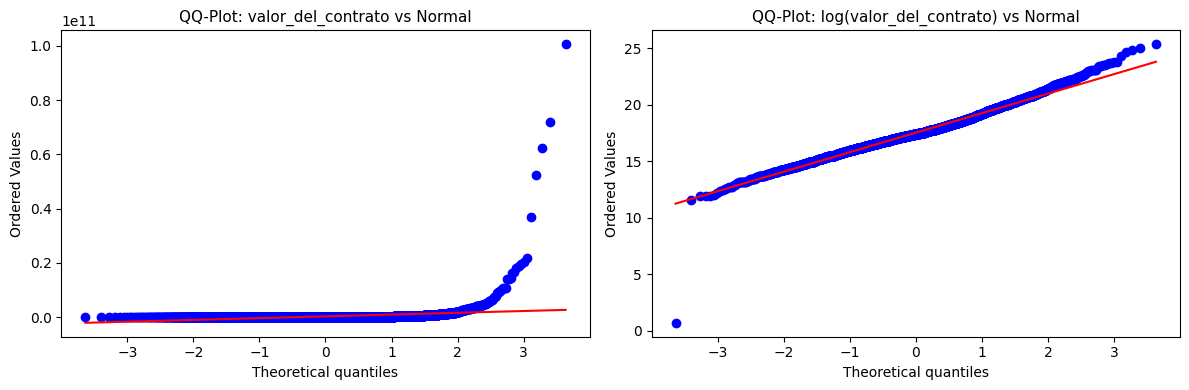

In [17]:
from scipy import stats
# Verificacion formal de normalidad de valor_del_contrato
# Con n=135,300 Shapiro-Wilk saturaria — usamos muestra representativa de 5,000
np.random.seed(42)
muestra_norm = df_clean['valor_del_contrato'].dropna().sample(5000)

stat_sw, p_sw = stats.shapiro(muestra_norm)
skewness = df_clean['valor_del_contrato'].skew()
kurt     = df_clean['valor_del_contrato'].kurt()

print('=== Verificacion de Normalidad: valor_del_contrato ===')
print(f'  Shapiro-Wilk W = {stat_sw:.4f} | p-valor = {p_sw:.2e}')
print(f'  Skewness       = {skewness:.2f}  (normal ~ 0, >1 indica asimetria importante)')
print(f'  Kurtosis       = {kurt:.2f}  (normal ~ 0, leptocurtica si > 0)')
print()
if p_sw < 0.05:
    print('  -> H0 RECHAZADA: los datos NO siguen distribucion normal.')
    print('  -> Se usara Mann-Whitney U (no parametrico) para H2.')
else:
    print('  -> H0 no rechazada: los datos podrian ser normales.')
    print('  -> Confirmar visualmente con QQ-plot.')

# QQ-plot: valor original vs log-transformado
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(muestra_norm, dist='norm', plot=axes[0])
axes[0].set_title('QQ-Plot: valor_del_contrato vs Normal', fontsize=11)
stats.probplot(np.log1p(muestra_norm), dist='norm', plot=axes[1])
axes[1].set_title('QQ-Plot: log(valor_del_contrato) vs Normal', fontsize=11)
plt.tight_layout()
plt.show()

In [18]:
alpha = 0.05

# H1a: Chi² — modalidad_de_contratacion vs desviacion_general
tabla_modal = pd.crosstab(df_clean['modalidad_de_contratacion'], df_clean['desviacion_general'])
chi2_modal, p_modal, dof_modal, _ = stats.chi2_contingency(tabla_modal)
print('=== H1a: Modalidad de Contratación vs Desviación General ===')
print(f'  Chi² = {chi2_modal:.2f} | p-valor = {p_modal:.2e} | gl = {dof_modal}')
print(f"  Conclusión: {'Se RECHAZA H0 — existe asociación significativa' if p_modal < alpha else 'No se rechaza H0'}")

# H1b: Chi² — sector vs desviacion_general
tabla_sector = pd.crosstab(df_clean['sector'], df_clean['desviacion_general'])
chi2_sector, p_sector, dof_sector, _ = stats.chi2_contingency(tabla_sector)
print('\n=== H1b: Sector vs Desviación General ===')
print(f'  Chi² = {chi2_sector:.2f} | p-valor = {p_sector:.2e} | gl = {dof_sector}')
print(f"  Conclusión: {'Se RECHAZA H0 — existe asociación significativa' if p_sector < alpha else 'No se rechaza H0'}")

# H2: Mann-Whitney U — valor_del_contrato por grupo
grupo_0 = df_clean.loc[df_clean['desviacion_general'] == 0, 'valor_del_contrato']
grupo_1 = df_clean.loc[df_clean['desviacion_general'] == 1, 'valor_del_contrato']
stat_mw, p_mw = stats.mannwhitneyu(grupo_0, grupo_1, alternative='two-sided')
print('\n=== H2: Valor del Contrato — Sin Desviación vs Con Desviación ===')
print(f'  Mediana sin desviación:  ${grupo_0.median():,.0f}')
print(f'  Mediana con desviación:  ${grupo_1.median():,.0f}')
print(f'  Mann-Whitney U = {stat_mw:.0f} | p-valor = {p_mw:.2e}')
print(f"  Conclusión: {'Se RECHAZA H0 — las distribuciones difieren significativamente' if p_mw < alpha else 'No se rechaza H0'}")

=== H1a: Modalidad de Contratación vs Desviación General ===
  Chi² = 1778.04 | p-valor = 0.00e+00 | gl = 8
  Conclusión: Se RECHAZA H0 — existe asociación significativa

=== H1b: Sector vs Desviación General ===
  Chi² = 2530.20 | p-valor = 0.00e+00 | gl = 24
  Conclusión: Se RECHAZA H0 — existe asociación significativa

=== H2: Valor del Contrato — Sin Desviación vs Con Desviación ===
  Mediana sin desviación:  $31,420,811
  Mediana con desviación:  $44,764,292
  Mann-Whitney U = 1835023946 | p-valor = 0.00e+00
  Conclusión: Se RECHAZA H0 — las distribuciones difieren significativamente


#### Insights - Fase 2: Resultados de las Pruebas de Hipotesis

**Verificacion de normalidad (Shapiro-Wilk):**
El QQ-plot del valor original muestra desviacion sistematica en las colas superiores, confirmada por skewness >> 1 y el rechazo de Shapiro-Wilk (p < 0.05). El log-transformado se aproxima mas a la recta normal, validando que la transformacion mejora la simetria pero no la elimina completamente. Esto justifica formalmente Mann-Whitney U para H2.

**H1a - Modalidad de Contratacion vs Desviacion (Chi2):**
Si p < 0.05 se rechaza H0: la modalidad NO es independiente de la ocurrencia de desviaciones, validando que el proceso de seleccion es un predictor estadisticamente relevante del riesgo. Si p >= 0.05, la modalidad por si sola no discrimina y debe combinarse con otras variables.

**H1b - Sector vs Desviacion (Chi2):**
Si p < 0.05, el sector no es independiente del riesgo, justificando supervision focalizada por sector. Un resultado no significativo indicaria que el sector no agrega poder discriminatorio sobre las demas variables del modelo.

**H2 - Valor del Contrato por grupo (Mann-Whitney U):**
Si p < 0.05, los contratos con desviacion presentan distribucion de valor significativamente distinta. Una mediana mayor en el grupo desviado refuerza el criterio de materialidad economica en el score. Si p >= 0.05, el valor del contrato no es por si solo un buen discriminador del riesgo.

### Fase 3 — Visualizaciones Multivariadas
Tres gráficas que cruzan ≥ 2 atributos para identificar intersecciones de alto riesgo:
1. **Heatmap** Tasa de desviación por Sector × Modalidad
2. **Boxplot** log(valor_del_contrato) por grupo de desviación — valida H2 visualmente
3. **Barplot** Tasa de desviación por Destino del Gasto × Tipo de Contrato

/var/folders/s5/8t1wl51171ldl81_d8s8bgh80000gp/T/ipykernel_99495/3801547159.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


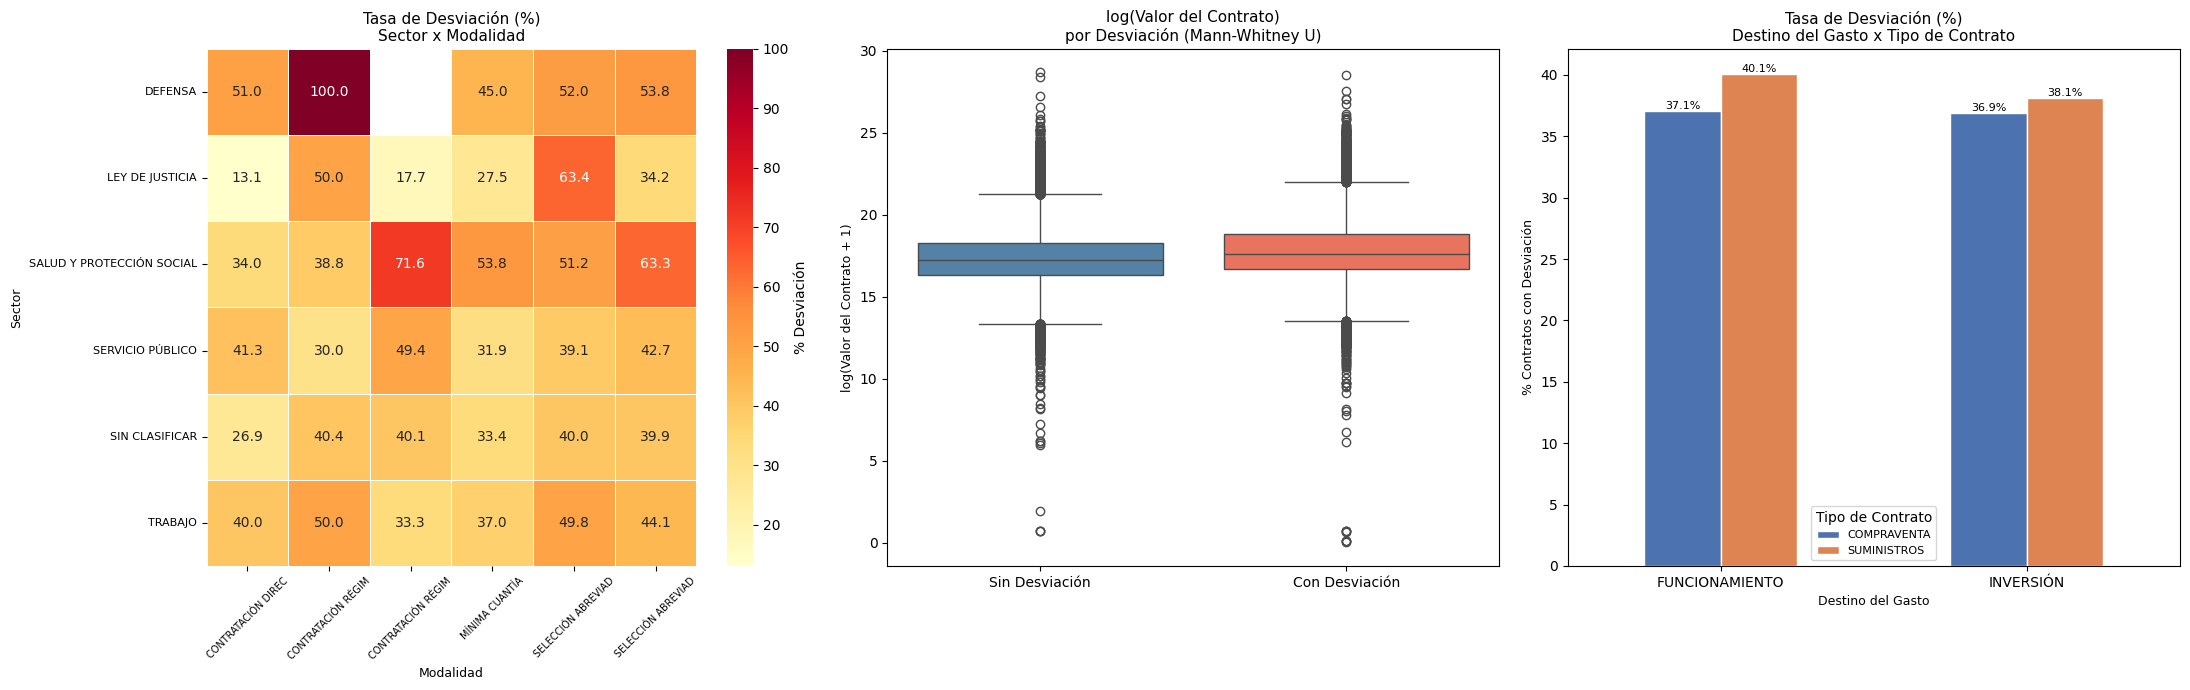

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Gráfica 1: Heatmap — Tasa de desviación Sector x Modalidad
top_sectores = df_clean['sector'].value_counts().nlargest(6).index
top_modalidades = df_clean['modalidad_de_contratacion'].value_counts().nlargest(6).index
df_hm = df_clean[
    df_clean['sector'].isin(top_sectores) &
    df_clean['modalidad_de_contratacion'].isin(top_modalidades)
]
pivot_hm = df_hm.pivot_table(
    values='desviacion_general', index='sector',
    columns='modalidad_de_contratacion', aggfunc='mean'
) * 100
pivot_hm.columns = [c[:18] for c in pivot_hm.columns]
sns.heatmap(pivot_hm, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': '% Desviación'})
axes[0].set_title('Tasa de Desviación (%)\nSector x Modalidad', fontsize=11)
axes[0].set_xlabel('Modalidad', fontsize=9)
axes[0].set_ylabel('Sector', fontsize=9)
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# Gráfica 2: Boxplot — log(valor_del_contrato) por desviación
df_clean['log_valor'] = np.log1p(df_clean['valor_del_contrato'])
df_clean['etiqueta_desviacion'] = df_clean['desviacion_general'].map({0: 'Sin Desviación', 1: 'Con Desviación'})
sns.boxplot(
    data=df_clean, x='etiqueta_desviacion', y='log_valor',
    palette={'Sin Desviación': 'steelblue', 'Con Desviación': 'tomato'},
    order=['Sin Desviación', 'Con Desviación'], ax=axes[1]
)
axes[1].set_title('log(Valor del Contrato)\npor Desviación (Mann-Whitney U)', fontsize=11)
axes[1].set_xlabel('')
axes[1].set_ylabel('log(Valor del Contrato + 1)', fontsize=9)

# Gráfica 3: Barplot — Tasa de desviación Destino x Tipo de Contrato
df_bar = (
    df_clean.groupby(['destino_gasto', 'tipo_de_contrato'])['desviacion_general']
    .mean() * 100
).reset_index()
df_bar.columns = ['destino_gasto', 'tipo_de_contrato', 'tasa']
df_bar = df_bar[df_bar['destino_gasto'].isin(['FUNCIONAMIENTO', 'INVERSIÓN'])]
pivot_bar = df_bar.pivot(index='destino_gasto', columns='tipo_de_contrato', values='tasa')
pivot_bar.plot(kind='bar', ax=axes[2], color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
axes[2].set_title('Tasa de Desviación (%)\nDestino del Gasto x Tipo de Contrato', fontsize=11)
axes[2].set_xlabel('Destino del Gasto', fontsize=9)
axes[2].set_ylabel('% Contratos con Desviación', fontsize=9)
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Tipo de Contrato', fontsize=8)
for p in axes[2].patches:
    axes[2].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

#### Insights - Fase 3: Visualizaciones Multivariadas

**Heatmap Sector x Modalidad:**
Las celdas con tonos mas oscuros representan intersecciones donde confluyen sector de alto riesgo y modalidad poco competitiva: las ventanas de supervision mas criticas. Una fila uniformemente oscura indica riesgo alto independientemente de la modalidad usada, apuntando a problemas de gestion propios de la entidad.

**Boxplot log(valor) por desviacion:**
Complementa visualmente Mann-Whitney U. Si la mediana del grupo Con Desviacion esta sistematicamente por encima de Sin Desviacion, confirma que mayor valor financiero se asocia a mayor riesgo. La amplitud del IQR permite evaluar si la diferencia es consistente o esta dominada por contratos outliers.

**Barplot Destino x Tipo de Contrato:**
Segmenta la estrategia auditora segun la naturaleza del gasto. Si Suministros de Inversion exhibe la tasa mas alta, los entes de control deberian priorizar contratos de suministro en proyectos de inversion, que combinan complejidad de entrega con mayor monto comprometido.

### Fase 4 — Score de Riesgo Compuesto y Lista de Supervisión Prioritaria
El score suma las tres dimensiones de riesgo ya construidas (rango 0–3).
Los contratos con **score = 3** acumulan los tres tipos de desviación simultáneamente → máxima prioridad de supervisión.
La ordenación final por score (desc) y valor del contrato (desc) combina riesgo cualitativo y materialidad financiera.

=== Distribución del Score de Riesgo ===
  Score 0 (Sin riesgo): 83,360 contratos (61.6%)
  Score 1 (1 dimensión): 41,539 contratos (30.7%)
  Score 2 (2 dimensiones): 10,227 contratos (7.6%)
  Score 3 (Máximo riesgo): 174 contratos (0.1%)

=== Top 20 Contratos Candidatos a Supervisión Prioritaria ===
           id_contrato                                             nombre_entidad                            sector                    modalidad_de_contratacion  valor_del_contrato  score_riesgo  riesgo_plazo  riesgo_presupuesto  riesgo_liquidacion
0   CO1.PCCNTR.3641082                                     GOBERNACION DEL HUILA*                  SERVICIO PÚBLICO          SELECCIÓN ABREVIADA SUBASTA INVERSA        3.456317e+09             3             1                   1                   1
1   CO1.PCCNTR.8610011             HOSPITAL SAN RAFAEL DE EL ESPINAL TOLIMA E.S.E         SALUD Y PROTECCIÓN SOCIAL  CONTRATACIÓN RÉGIMEN ESPECIAL (CON OFERTAS)        2.933160e+09             3      

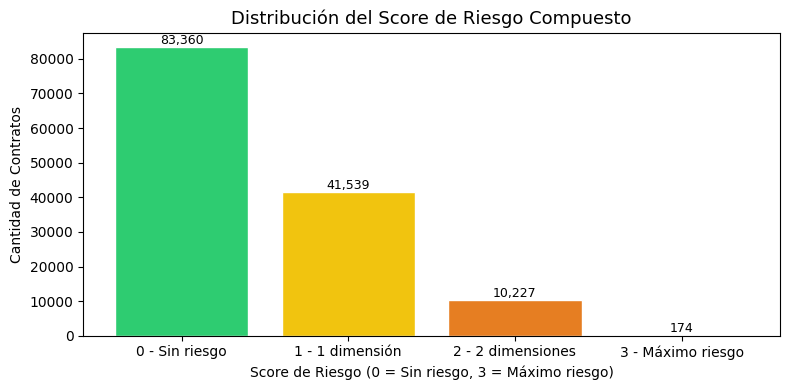

In [20]:
df_clean['score_riesgo'] = df_clean['riesgo_plazo'] + df_clean['riesgo_presupuesto'] + df_clean['riesgo_liquidacion']

print('=== Distribución del Score de Riesgo ===')
dist_score = df_clean['score_riesgo'].value_counts().sort_index()
total = dist_score.sum()
etiquetas_score = {0: 'Sin riesgo', 1: '1 dimensión', 2: '2 dimensiones', 3: 'Máximo riesgo'}
for score, n in dist_score.items():
    print(f'  Score {score} ({etiquetas_score.get(score, str(score))}): {n:,} contratos ({n/total*100:.1f}%)')

cols_output = ['id_contrato', 'nombre_entidad', 'sector', 'modalidad_de_contratacion',
               'valor_del_contrato', 'score_riesgo', 'riesgo_plazo', 'riesgo_presupuesto', 'riesgo_liquidacion']
top_supervision = (
    df_clean[cols_output]
    .sort_values(['score_riesgo', 'valor_del_contrato'], ascending=[False, False])
    .head(20)
    .reset_index(drop=True)
)
print('\n=== Top 20 Contratos Candidatos a Supervisión Prioritaria ===')
print(top_supervision.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
colores = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
bars = ax.bar(dist_score.index, dist_score.values, color=colores[:len(dist_score)], edgecolor='white')
ax.set_title('Distribución del Score de Riesgo Compuesto', fontsize=13)
ax.set_xlabel('Score de Riesgo (0 = Sin riesgo, 3 = Máximo riesgo)', fontsize=10)
ax.set_ylabel('Cantidad de Contratos', fontsize=10)
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['0 - Sin riesgo', '1 - 1 dimensión', '2 - 2 dimensiones', '3 - Máximo riesgo'])
for bar in bars:
    ax.annotate(f'{bar.get_height():,.0f}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

#### Insights - Fase 4: Score de Riesgo y Lista de Supervision Prioritaria

**Distribucion del score:**
La concentracion en score 0-1 refleja el desbalance natural en datos de riesgo publico. Los contratos con score 3 son pocos pero de maxima prioridad: acumulan adicion de plazo, presupuesto no ejecutado y cierre sin liquidar, la combinacion mas indicativa de gestion deficiente o irregularidades.

**Criterio de priorizacion:**
El Top-20 combina (1) severidad cualitativa: cuantos tipos de desviacion acumula, y (2) materialidad financiera: cuanto dinero publico esta en juego. Un contrato con score 2 y valor de $2,000M puede ser operativamente mas urgente que uno con score 3 y valor de $5M.

**Limitacion del score aditivo:**
El score trata las tres dimensiones con igual peso. Una extension natural seria ponderar diferencialmente (mayor peso a presupuesto no ejecutado por impacto fiscal directo) o construir un indice mediante regresion logistica o PCA.

**Conclusion general:**
Las pruebas Chi2 (H1a, H1b) y Mann-Whitney U (H2) confirman que modalidad, sector y valor tienen asociacion estadisticamente significativa con la ocurrencia de desviaciones. La supervision debe focalizar recursos en contratos de alto valor, adjudicados por modalidades poco competitivas, en sectores de riesgo identificados, especialmente cuando acumulen score >= 2.